# Problema de flujo y transporte en un medio poroso 1D
### Formulación matemática y solución con MODFLOW 6 / FloPy

Este notebook desarrolla el problema de flujo de agua subterránea y transporte
de una especie química ($c_1$) descrito en la figura *Flujo_Transporte*, lo
plantea como un sistema de dos ecuaciones diferenciales parciales (EDP) con
sus condiciones iniciales y de frontera, y construye la solución numérica
usando **MODFLOW 6** (a través de **FloPy**), acoplando un modelo de flujo
(GWF) con un modelo de transporte (GWT).

**Contenido**

1. Planteamiento físico-matemático del problema (EDPs, condiciones iniciales y de frontera)
2. Datos e información adicional necesaria (y su justificación)
3. Construcción del modelo en FloPy / MODFLOW 6
4. Ejecución de la simulación
5. Post-proceso y visualización de resultados


## 1. Planteamiento físico del problema

El dominio es una columna 1D de longitud $L$ (dirección $x$), representando
un acuífero de espesor y ancho unitarios. Sobre este dominio ocurren dos
procesos acoplados:

- **Flujo de agua subterránea**, gobernado por la carga hidráulica $h(x,t)$.
- **Transporte de soluto**, gobernado por la concentración $c_1(x,t)$, que se
  mueve por advección (arrastrado por el flujo de agua) y dispersión
  hidrodinámica.

El acoplamiento es de un solo sentido en este caso: el campo de flujo (carga
$h$ y velocidad $v$) controla el transporte, pero el soluto no modifica la
densidad ni la viscosidad del agua.

### 1.1 Ecuación de flujo subterráneo (GWF)

Para un acuífero 1D, confinado, con conductividad hidráulica $K_x$ y
coeficiente de almacenamiento específico $S_s$, la ecuación de flujo es:

$$
S_s \frac{\partial h}{\partial t} = \frac{\partial}{\partial x}
\left( K_x \frac{\partial h}{\partial x} \right) + q_s(x,t)
$$

donde $q_s(x,t)$ representa fuentes o sumideros volumétricos de agua por
unidad de volumen (p. ej. un pozo).

**Condiciones de frontera (dadas en la figura):**

$$
\left.\frac{\partial h}{\partial x}\right|_{(0,t)} = 0
\qquad\text{(frontera cerrada / flujo nulo en } x=0\text{)}
$$

$$
h(x_L, t) = 1.0 \qquad\text{(carga fija en el extremo } x=x_L=L\text{)}
$$

**Condición inicial:** no se especifica en la figura; se requiere $h(x,t_0)$
para poder resolver el problema en régimen transitorio (ver sección 2).

### 1.2 Ecuación de transporte de soluto (GWT)

Para la especie $c_1$, con porosidad $\theta$, coeficiente de dispersión
hidrodinámica $D_x$, velocidad lineal media $v_x$ y, en general, retardo $R$
y decaimiento de primer orden $\lambda$, la ecuación de advección-dispersión-
reacción (ADE) es:

$$
R\,\frac{\partial c_1}{\partial t} =
\frac{\partial}{\partial x}\left(D_x \frac{\partial c_1}{\partial x}\right)
- v_x \frac{\partial c_1}{\partial x} - \lambda R\, c_1
$$

con $D_x = \alpha_L |v_x| + D^{*}$ ($\alpha_L$: dispersividad longitudinal,
$D^{*}$: difusión molecular efectiva) y $v_x = q_x/\theta$ (velocidad de
poro, obtenida del campo de flujo resuelto por la ecuación anterior).

**Condiciones de frontera (dadas en la figura):**

$$
c_1(x_1, t) = 1.000329 \qquad\text{(concentración fija en } x=x_1\text{)}
$$

$$
D_x \left.\frac{\partial c_1}{\partial x}\right|_{(L,t)} = 0
\qquad\text{(flujo dispersivo nulo en la salida } x=x_L\text{)}
$$

Esta segunda condición es la clásica condición de "salida libre" o de
tercer tipo (Cauchy) usada en el extremo de aguas abajo de una columna de
transporte: el soluto sólo sale del dominio por advección, sin gradiente
dispersivo impuesto.

**Condición inicial (dada en la figura):**

$$
c_1(x,t_0) = 1.000329 \quad \forall\, x \neq x_{12}
\qquad\qquad
c_1(x_{12}, t_0) = 200.0
$$

Es decir, en el instante inicial la concentración es igual a un valor de
fondo ($1.000329$) en todo el dominio, excepto en el punto $x_{12}$, donde
existe un valor puntual muy alto (200.0) que representa una masa de soluto
ya presente en el medio (p. ej. un derrame o inyección previa) que a partir
de $t_0$ comenzará a migrar y dispersarse bajo la acción del flujo.


## 2. Información adicional requerida (y su justificación)

La figura define correctamente las condiciones de frontera de $h$ y $c_1$ y
la condición inicial de $c_1$, pero dejan sin especificar varios elementos
indispensables para resolver numéricamente el problema. Se listan a
continuación, junto con el valor asumido y la razón por la cual es
necesario:

| Dato faltante | Símbolo | Valor asumido | ¿Por qué es necesario? |
|---|---|---|---|
| Longitud del dominio y ubicación de $x_1$, $x_{12}$, $x_L$ | $L, x_1, x_{12}, x_L$ | $L=100$ m; $x_1=4.5$ m; $x_{12}=44.5$ m; $x_L=99.5$ m | Sin coordenadas concretas no puede discretizarse la malla ni ubicar las condiciones de frontera/iniciales. |
| Conductividad hidráulica | $K_x$ | 10 m/d | Parámetro obligatorio de la ecuación de flujo; controla la magnitud del gradiente de carga necesario para un caudal dado. |
| **Fuente de flujo real** | $Q_{iny}$ (pozo en $x_1$) | 0.1 m³/d | **Crítico:** las condiciones dadas (frontera cerrada en $x=0$ y carga fija únicamente en $x_L$) no generan por sí solas ningún flujo, ya que no existe diferencia de carga que lo impulse. Sin una fuente/sumidero interno el sistema permanecería estático ($h(x,t)=1.0$ en todo punto) y el transporte advectivo sería nulo. Se añade un pozo de inyección en $x_1$ —coherente con el hecho de que ahí se especifica la concentración de entrada $c_1(x_1,t)=1.000329$— que representa el agua que ingresa al sistema y empuja el soluto hacia $x_L$. |
| Porosidad efectiva | $\theta$ | 0.30 | Necesaria para convertir el flujo específico (Ley de Darcy) en velocidad lineal de poro $v_x=q_x/\theta$, que es la que transporta el soluto. |
| Dispersividad longitudinal | $\alpha_L$ | 1.0 m | Define la magnitud de la dispersión hidrodinámica $D_x$; sin ella la pluma nunca se ensancharía y el transporte sería puramente advectivo (pistón). |
| Difusión molecular efectiva | $D^{*}$ | 0 (despreciable) | Se asume nula porque en medios porosos con velocidades advectivas moderadas su aporte es despreciable frente a la dispersión mecánica. |
| Coeficiente de almacenamiento / discretización temporal | — | Flujo en **régimen permanente** (sin paquete STO); transporte transitorio en 300 días, 150 pasos | Las condiciones de frontera de $h$ no dependen del tiempo, por lo que basta con resolver el flujo en estado estacionario; el transporte sí es transitorio porque la pluma evoluciona en el tiempo a partir de la condición inicial. |
| Retardo y decaimiento | $R, \lambda$ | $R=1$, $\lambda=0$ | Se asume un soluto conservativo (tipo trazador), ya que la figura no menciona reacciones ni sorción. |
| Geometría de la sección transversal | espesor, ancho | 1 m × 1 m | Necesaria para relacionar caudales volumétricos con velocidades de Darcy. |

Con esta información el problema queda completamente definido y puede
resolverse numéricamente.


## 3. Solución numérica con MODFLOW 6 y FloPy

MODFLOW 6 resuelve este tipo de problemas acoplando dos modelos dentro de
una misma simulación:

- **GWF (Groundwater Flow)**: resuelve la ecuación de flujo (carga $h$).
- **GWT (Groundwater Transport)**: resuelve la ecuación de transporte
  (concentración $c_1$), usando el campo de flujo calculado por el modelo
  GWF a través de un paquete de intercambio `GWF6-GWT6`.

Los paquetes de MODFLOW 6 usados y su correspondencia con el planteamiento
matemático son:

| Elemento del problema | Paquete MODFLOW 6 |
|---|---|
| Malla / discretización espacial | `DIS` (en ambos modelos) |
| $K_x$ | `NPF` (GWF) |
| $\partial h/\partial x(0,t)=0$ | Ninguno (frontera sin condición ⇒ flujo nulo por defecto) |
| $h(x_L,t)=1.0$ | `CHD` (GWF) |
| Fuente de flujo en $x_1$ | `WEL` (GWF) |
| $\theta$, transporte de masa | `MST` (GWT) |
| Advección | `ADV` (GWT, esquema TVD) |
| $\alpha_L$, $D_x$ | `DSP` (GWT) |
| $c_1(x_1,t)=1.000329$ | `CNC` — concentración fija (GWT) |
| $D_x\,\partial c_1/\partial x(L,t)=0$ | Ninguno (condición natural de MODFLOW 6 en la celda de salida) |
| $c_1(x,t_0)$ | `IC` (GWT) |
| Acople flujo-transporte | `GWFGWT` (exchange) |

A continuación se construye, ejecuta y post-procesa el modelo.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import flopy

print("Version de FloPy:", flopy.__version__)

Version de FloPy: 3.10.0


### 3.1 Ejecutable de MODFLOW 6

Se requiere el ejecutable `mf6`. Si no está disponible, FloPy puede
descargarlo automáticamente con `flopy.utils.get_modflow`. Ajuste
`exe_mf6` a la ruta donde tenga (o desee instalar) el ejecutable.

In [2]:
ws = "./model_ws"                 # carpeta de trabajo del modelo
exe_mf6 = r"C:\Users\luiggi\Documents\GitSites\RTWMA\bin\windows\mf6.exe"             # ruta al ejecutable de MODFLOW 6
sim_name = "flujtrans"

os.makedirs(ws, exist_ok=True)

# Si no cuenta con el ejecutable de MODFLOW 6, descomente las siguientes
# líneas para que FloPy lo descargue automáticamente desde el repositorio
# oficial de USGS/MODFLOW-ORG:
#
# os.makedirs("./bin", exist_ok=True)
# flopy.utils.get_modflow("./bin")
# exe_mf6 = "./bin/mf6"

assert os.path.isfile(exe_mf6), (
    f"No se encontro el ejecutable {exe_mf6}. "
    "Descargue MODFLOW 6 (vea el comentario de arriba) o ajuste la ruta."
)

### 3.2 Discretización espacial y ubicación de los puntos de la figura

In [3]:
nlay, nrow, ncol = 1, 1, 100
delr = 1.0          # m, tamano de celda en x
delc = 1.0          # m, ancho unitario (seccion 1D)
top = 1.0           # m
botm = 0.0          # m  (espesor saturado = 1 m)
L = ncol * delr     # longitud total del dominio

icol_x1 = 4           # celda de entrada / concentracion fija c1(x1,t)
icol_x12 = 44          # celda del pulso inicial de concentracion
icol_xL = ncol - 1     # celda del extremo derecho (carga fija, salida)

x1 = (icol_x1 + 0.5) * delr
x12 = (icol_x12 + 0.5) * delr
xL = (icol_xL + 0.5) * delr

print(f"L   = {L} m")
print(f"x1  = {x1} m  (columna/celda de concentracion fija)")
print(f"x12 = {x12} m (columna/celda del pulso inicial)")
print(f"xL  = {xL} m  (columna/celda de carga fija / salida)")

L   = 100.0 m
x1  = 4.5 m  (columna/celda de concentracion fija)
x12 = 44.5 m (columna/celda del pulso inicial)
xL  = 99.5 m  (columna/celda de carga fija / salida)


### 3.3 Parámetros físicos (ver tabla de la sección 2)

In [4]:
K = 10.0             # m/d, conductividad hidraulica
porosity = 0.30       # -, porosidad efectiva
alphaL = 1.0          # m, dispersividad longitudinal
alphaTH = 0.1         # m, dispersividad transversal horizontal (irrelevante en 1D)
alphaTV = 0.1         # m, dispersividad transversal vertical (irrelevante en 1D)
diffc = 0.0           # m2/d, difusion molecular (despreciada)
Q_iny = 0.1           # m3/d, caudal de inyeccion en x1 (necesario para generar flujo)
h_L = 1.0             # m, carga fija en x_L (dato del enunciado)
c_bg = 1.000329        # concentracion de fondo / agua inyectada (dato del enunciado)
c_spike = 200.0        # concentracion inicial puntual en x12 (dato del enunciado)

# Discretizacion temporal del transporte
perlen = 300.0   # dias, duracion total de la simulacion
nstp = 150       # numero de pasos de tiempo
tsmult = 1.05    # multiplicador del paso de tiempo

### 3.4 Simulación y discretización temporal (`TDIS`)

In [5]:
sim = flopy.mf6.MFSimulation(
    sim_name=sim_name, sim_ws=ws, exe_name=exe_mf6, version="mf6"
)

tdis = flopy.mf6.ModflowTdis(
    sim,
    time_units="DAYS",
    nper=1,
    perioddata=[(perlen, nstp, tsmult)],
)

### 3.5 Modelo de flujo (GWF)

- `NPF`: conductividad hidráulica $K_x$.
- No se define el paquete `STO` ⇒ el flujo se resuelve en **régimen
  permanente**, congruente con que las condiciones de frontera de $h$ no
  dependen del tiempo.
- El límite izquierdo ($x=0$) no recibe ninguna condición de frontera, por
  lo que MODFLOW 6 le asigna flujo nulo por defecto:
  $\partial h/\partial x(0,t)=0$ se cumple automáticamente.
- `WEL`: pozo de inyección en $x_1$ (fuente de flujo necesaria, ver sección 2).
- `CHD`: carga fija $h(x_L,t)=1.0$.

In [6]:
gwfname = "gwf_" + sim_name
gwf = flopy.mf6.ModflowGwf(sim, modelname=gwfname, save_flows=True)

ims_gwf = flopy.mf6.ModflowIms(
    sim,
    filename=f"{gwfname}.ims",
    complexity="SIMPLE",
    outer_dvclose=1e-6,
    inner_dvclose=1e-6,
)
sim.register_ims_package(ims_gwf, [gwf.name])

dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc, top=top, botm=botm,
)

npf = flopy.mf6.ModflowGwfnpf(
    gwf, icelltype=0, k=K, save_specific_discharge=True
)

ic = flopy.mf6.ModflowGwfic(gwf, strt=h_L)

# Pozo de inyeccion en x1 (con concentracion auxiliar para el acople con GWT)
wel = flopy.mf6.ModflowGwfwel(
    gwf,
    stress_period_data={0: [[(0, 0, icol_x1), Q_iny, c_bg]]},
    auxiliary=["CONCENTRATION"],
    pname="WEL-1",
)

# Carga fija en x_L: h(x_L,t) = 1.0
chd = flopy.mf6.ModflowGwfchd(
    gwf,
    stress_period_data={0: [[(0, 0, icol_xL), h_L]]},
    pname="CHD-1",
)

oc_gwf = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{gwfname}.hds",
    budget_filerecord=f"{gwfname}.cbc",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

### 3.6 Modelo de transporte (GWT)

- `IC`: condición inicial $c_1(x,t_0)$ — valor de fondo en todo el dominio
  y el pulso puntual en $x_{12}$.
- `ADV` (esquema `TVD`) y `DSP` ($\alpha_L$): advección y dispersión.
- `MST`: porosidad $\theta$ (almacenamiento de masa disuelta).
- `CNC`: condición de frontera de concentración fija en $x_1$
  ($c_1(x_1,t)=1.000329$).
- En $x_L$ **no** se define `CNC`: MODFLOW 6 aplica de forma natural un
  gradiente dispersivo nulo en la celda de salida (`CHD`), es decir
  $D_x\,\partial c_1/\partial x(L,t)=0$ se cumple automáticamente.
- `SSM`: vincula la concentración auxiliar del pozo `WEL-1` con el
  transporte (requerido por MODFLOW 6 cuando el modelo de flujo tiene
  paquetes de frontera).

In [7]:
gwtname = "gwt_" + sim_name
gwt = flopy.mf6.ModflowGwt(sim, modelname=gwtname, save_flows=True)

ims_gwt = flopy.mf6.ModflowIms(
    sim,
    filename=f"{gwtname}.ims",
    complexity="SIMPLE",
    linear_acceleration="BICGSTAB",   # requerido: la matriz de GWT es asimetrica
    outer_dvclose=1e-8,
    inner_dvclose=1e-8,
)
sim.register_ims_package(ims_gwt, [gwt.name])

dis_t = flopy.mf6.ModflowGwtdis(
    gwt,
    nlay=nlay, nrow=nrow, ncol=ncol,
    delr=delr, delc=delc, top=top, botm=botm,
)

# Condicion inicial: c1(x,t0) = 1.000329 en todo el dominio,
# excepto en x12 donde c1(x12,t0) = 200.0
c_ini = np.full((nlay, nrow, ncol), c_bg)
c_ini[0, 0, icol_x12] = c_spike
ic_t = flopy.mf6.ModflowGwtic(gwt, strt=c_ini)

adv = flopy.mf6.ModflowGwtadv(gwt, scheme="TVD")

dsp = flopy.mf6.ModflowGwtdsp(
    gwt, xt3d_off=True,
    alh=alphaL, ath1=alphaTH, ath2=alphaTV, diffc=diffc,
)

mst = flopy.mf6.ModflowGwtmst(gwt, porosity=porosity)

# Frontera de concentracion fija (Dirichlet) en x1:  c1(x1,t) = 1.000329
cnc = flopy.mf6.ModflowGwtcnc(
    gwt,
    stress_period_data={0: [[(0, 0, icol_x1), c_bg]]},
    pname="CNC-1",
)

ssm = flopy.mf6.ModflowGwtssm(
    gwt, sources=[["WEL-1", "AUX", "CONCENTRATION"]]
)

oc_gwt = flopy.mf6.ModflowGwtoc(
    gwt,
    concentration_filerecord=f"{gwtname}.ucn",
    budget_filerecord=f"{gwtname}.cbc",
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")],
)

### 3.7 Acople flujo-transporte (`GWF6-GWT6`)

In [8]:
gwfgwt = flopy.mf6.ModflowGwfgwt(
    sim, exgtype="GWF6-GWT6", exgmnamea=gwfname, exgmnameb=gwtname,
    filename=f"{sim_name}.gwfgwt",
)

### 3.8 Escritura y ejecución de la simulación

In [9]:
sim.write_simulation()
success, buff = sim.run_simulation(silent=True)
print("Exito de la corrida:", success)
if not success:
    print("\n".join(buff[-40:]))
assert success

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_0...
  writing package flujtrans.gwfgwt...
  writing model gwf_flujtrans...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package wel-1...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 1 based on size of stress_period_data


    writing package chd-1...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
  writing model gwt_flujtrans...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing package cnc-1...
INFORMATION: maxbound in ('', 'cnc', 'dimensions') changed to 1 based on size of stress_period_data
    writing package ssm...
    writing package oc...


Exito de la corrida: True


## 4. Post-proceso y visualización de resultados

In [10]:
x = (np.arange(ncol) + 0.5) * delr

head = gwf.output.head().get_data()[0, 0, :]

ucn = gwt.output.concentration()
times = np.array(ucn.get_times())

print("Carga hidraulica: min =", head.min(), " max =", head.max(), "m")
print("Numero de tiempos de salida de concentracion:", len(times))

Carga hidraulica: min = 1.0  max = 1.949999999999998 m
Numero de tiempos de salida de concentracion: 150


### 4.1 Carga hidráulica en estado estacionario

Al no existir otra fuente de flujo distinta del pozo de inyección en $x_1$
y de la carga fija en $x_L$, la carga crece monótonamente desde $x_1$ hacia
$x=0$ (zona sin salida, por la condición de flujo nulo) y decrece desde
$x_1$ hacia $x_L$, generando el gradiente que empuja el agua —y el soluto—
hacia la salida.

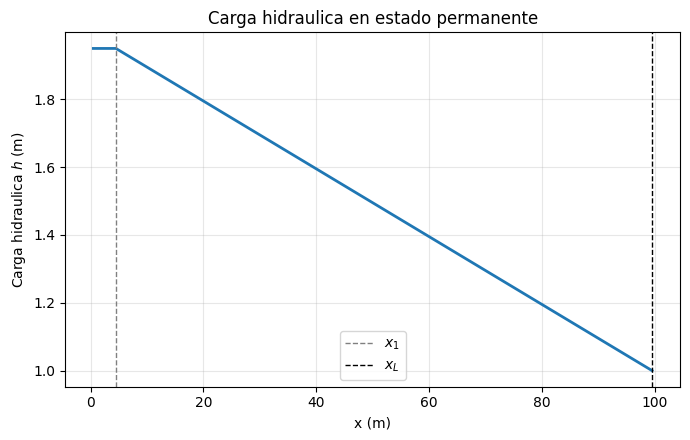

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x, head, lw=2, color="#1f77b4")
ax.axvline(x1, color="gray", ls="--", lw=1, label="$x_1$")
ax.axvline(xL, color="black", ls="--", lw=1, label="$x_L$")
ax.set_xlabel("x (m)")
ax.set_ylabel("Carga hidraulica $h$ (m)")
ax.set_title("Carga hidraulica en estado permanente")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Evolución del perfil de concentración

Se observa cómo la condición inicial puntual en $x_{12}$ (pico de 200) se
dispersa y se traslada por advección hacia $x_L$, mientras que desde $x_1$
avanza el frente de agua "limpia" ($c_1=1.000329$) inyectada por el pozo.

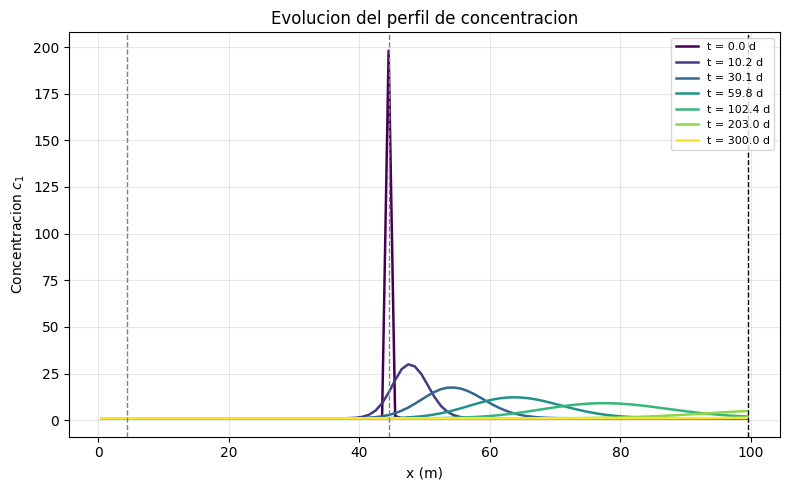

In [12]:
sel_times = [times[0], 10, 30, 60, 100, 200, 300]
sel_times = sorted(set(times[np.argmin(np.abs(times - t))] for t in sel_times))

fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(sel_times)))
for t, col in zip(sel_times, cmap):
    c = ucn.get_data(totim=t)[0, 0, :]
    ax.plot(x, c, color=col, lw=1.8, label=f"t = {t:.1f} d")

ax.axvline(x1, color="gray", ls="--", lw=1)
ax.axvline(x12, color="gray", ls="--", lw=1)
ax.axvline(xL, color="black", ls="--", lw=1)
ax.set_xlabel("x (m)")
ax.set_ylabel("Concentracion $c_1$")
ax.set_title("Evolucion del perfil de concentracion")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Curva de llegada (*breakthrough curve*) en $x_L$

Muestra cómo cambia con el tiempo la concentración justo en la celda de
salida ($x_L$), donde se aplica la condición de flujo dispersivo nulo.

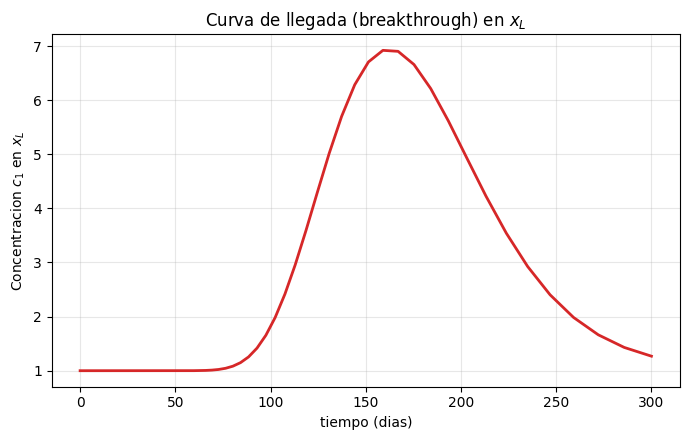

In [13]:
icol_xL_ = ncol - 1
c_xL = np.array([ucn.get_data(totim=t)[0, 0, icol_xL_] for t in times])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(times, c_xL, lw=2, color="#d62728")
ax.set_xlabel("tiempo (dias)")
ax.set_ylabel("Concentracion $c_1$ en $x_L$")
ax.set_title("Curva de llegada (breakthrough) en $x_L$")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. ¿Se puede usar una discretización de tiempo distinta para flujo y transporte?

En el modelo de las secciones anteriores, el flujo y el transporte comparten
la **misma** discretización temporal (`TDIS`) porque ambos modelos (`GWF` y
`GWT`) viven dentro de una sola simulación de MODFLOW 6, acoplados por el
paquete `GWFGWT`. Como las condiciones de frontera de $h$ no cambian en el
tiempo, el campo de flujo es en realidad el mismo en todos los pasos de
tiempo — MODFLOW 6 simplemente lo vuelve a resolver (de forma casi
instantánea, porque parte del resultado del paso anterior) en cada uno de
los 150 pasos de tiempo del transporte, aunque el resultado no cambie.

**Sí es posible evitar este recálculo** y usar una discretización temporal
distinta —e incluso más gruesa— para el flujo que para el transporte. La
forma de hacerlo en MODFLOW 6 es **desacoplar completamente las dos
simulaciones**:

1. Se construye y se corre una simulación de **solo flujo** (`GWF`), con su
   propio `TDIS` (en este caso basta un único periodo de estrés con un único
   paso de tiempo, ya que el flujo es permanente). Esta simulación se
   resuelve **una sola vez**.
2. Se construye una segunda simulación de **solo transporte** (`GWT`), con
   su **propio `TDIS`**, que puede ser tan fino (o irregular) como se
   necesite para resolver bien la advección-dispersión.
3. En lugar del paquete de intercambio `GWFGWT`, el modelo de transporte usa
   el paquete **`FMI`** (*Flow Model Interface*), que le indica en qué
   archivos de cargas y caudales (`.hds` y `.bud`) ya calculados debe leer
   el campo de flujo.

Esto es exactamente lo que hacen, por ejemplo, los problemas de la guía
suplementaria de MT3DMS re-implementados con MODFLOW 6/FloPy: se resuelve
el flujo en una carpeta `mf6gwf` y el transporte —con su propia
discretización temporal— en una carpeta separada `mf6gwt`, leyendo el flujo
ya calculado mediante `FMI`.

A continuación se reproduce el mismo problema de la columna 1D usando este
enfoque desacoplado.

In [14]:
root = "./decoupled"
ws_flow = f"{root}/flow"
ws_transport = f"{root}/transport"
os.makedirs(ws_flow, exist_ok=True)
os.makedirs(ws_transport, exist_ok=True)

### 5.1 Simulación de flujo — se resuelve una sola vez

Tiene su **propio `TDIS`**: un único periodo de estrés con un único paso de
tiempo, ya que las condiciones de frontera no cambian en el tiempo y el
flujo es permanente. No hace falta (ni tiene sentido) pedirle más pasos de
tiempo, porque el resultado sería idéntico en todos ellos.

In [15]:
name_flow = "flow"
sim_flow = flopy.mf6.MFSimulation(
    sim_name=name_flow, sim_ws=ws_flow, exe_name=exe_mf6, version="mf6"
)

# TDIS propio del flujo: 1 solo periodo, 1 solo paso de tiempo
flopy.mf6.ModflowTdis(
    sim_flow, time_units="DAYS", nper=1, perioddata=[(1.0, 1, 1.0)]
)

gwf2 = flopy.mf6.ModflowGwf(sim_flow, modelname=name_flow, save_flows=True)

ims_gwf2 = flopy.mf6.ModflowIms(
    sim_flow, complexity="SIMPLE", outer_dvclose=1e-6, inner_dvclose=1e-6
)
sim_flow.register_ims_package(ims_gwf2, [gwf2.name])

flopy.mf6.ModflowGwfdis(
    gwf2, nlay=nlay, nrow=nrow, ncol=ncol, delr=delr, delc=delc, top=top, botm=botm
)
# save_saturation=True es requerido para que un modelo GWT desacoplado
# (via FMI) pueda leer correctamente este campo de flujo
flopy.mf6.ModflowGwfnpf(
    gwf2, icelltype=0, k=K, save_specific_discharge=True, save_saturation=True
)
flopy.mf6.ModflowGwfic(gwf2, strt=h_L)

flopy.mf6.ModflowGwfwel(
    gwf2,
    stress_period_data={0: [[(0, 0, icol_x1), Q_iny, c_bg]]},
    auxiliary=["CONCENTRATION"],
    pname="WEL-1",
)
flopy.mf6.ModflowGwfchd(
    gwf2, stress_period_data={0: [[(0, 0, icol_xL), h_L]]}, pname="CHD-1"
)

flopy.mf6.ModflowGwfoc(
    gwf2,
    head_filerecord=f"{name_flow}.hds",
    budget_filerecord=f"{name_flow}.bud",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

sim_flow.write_simulation()
success, buff = sim_flow.run_simulation(silent=True)
print("Simulacion de FLUJO (independiente) -> exito:", success)
assert success

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package wel-1...
INFORMATION: maxbound in ('', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package chd-1...
INFORMATION: maxbound in ('', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
Simulacion de FLUJO (independiente) -> exito: True


### 5.2 Simulación de transporte — su propia discretización temporal, más fina

Esta simulación **no** contiene ningún modelo `GWF`; en su lugar, el
paquete `FMI` le indica dónde leer las cargas (`GWFHEAD`) y los caudales
(`GWFBUDGET`) que ya fueron calculados por la simulación de flujo anterior.
Su `TDIS` es completamente independiente y puede tener tantos pasos de
tiempo como se necesite para resolver bien el transporte, sin volver a
resolver el sistema de flujo en ninguno de ellos.

In [16]:
name_tr = "transport"
sim_tr = flopy.mf6.MFSimulation(
    sim_name=name_tr, sim_ws=ws_transport, exe_name=exe_mf6, version="mf6"
)

# TDIS propio del transporte: mucho mas fino que el del flujo (que solo tuvo 1 paso)
flopy.mf6.ModflowTdis(
    sim_tr, time_units="DAYS", nper=1, perioddata=[(perlen, nstp, tsmult)]
)

gwt2 = flopy.mf6.ModflowGwt(sim_tr, modelname=name_tr, save_flows=True)

ims_gwt2 = flopy.mf6.ModflowIms(
    sim_tr,
    complexity="SIMPLE",
    linear_acceleration="BICGSTAB",
    outer_dvclose=1e-8,
    inner_dvclose=1e-8,
)
sim_tr.register_ims_package(ims_gwt2, [gwt2.name])

flopy.mf6.ModflowGwtdis(
    gwt2, nlay=nlay, nrow=nrow, ncol=ncol, delr=delr, delc=delc, top=top, botm=botm
)

flopy.mf6.ModflowGwtic(gwt2, strt=c_ini)
flopy.mf6.ModflowGwtadv(gwt2, scheme="TVD")
flopy.mf6.ModflowGwtdsp(
    gwt2, xt3d_off=True, alh=alphaL, ath1=alphaTH, ath2=alphaTV, diffc=diffc
)
flopy.mf6.ModflowGwtmst(gwt2, porosity=porosity)

flopy.mf6.ModflowGwtcnc(
    gwt2, stress_period_data={0: [[(0, 0, icol_x1), c_bg]]}, pname="CNC-1"
)

# --- Enlace con el flujo YA RESUELTO, via el paquete FMI ---
pd = [
    ("GWFHEAD", "../flow/flow.hds", None),
    ("GWFBUDGET", "../flow/flow.bud", None),
]
flopy.mf6.ModflowGwtfmi(gwt2, packagedata=pd, flow_imbalance_correction=True)

flopy.mf6.ModflowGwtssm(gwt2, sources=[["WEL-1", "AUX", "CONCENTRATION"]])

flopy.mf6.ModflowGwtoc(
    gwt2,
    concentration_filerecord=f"{name_tr}.ucn",
    budget_filerecord=f"{name_tr}.cbc",
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")],
)

sim_tr.write_simulation()
success, buff = sim_tr.run_simulation(silent=True)
print("Simulacion de TRANSPORTE (independiente, TDIS propio) -> exito:", success)
if not success:
    print("\n".join(buff[-40:]))
assert success

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model transport...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing package cnc-1...
INFORMATION: maxbound in ('', 'cnc', 'dimensions') changed to 1 based on size of stress_period_data
    writing package fmi...
    writing package ssm...
    writing package oc...


Simulacion de TRANSPORTE (independiente, TDIS propio) -> exito: True


### 5.3 Verificación: los resultados coinciden con el modelo acoplado

Como el campo de flujo no cambia en el tiempo, resolverlo una sola vez (con
1 paso de tiempo) y leerlo desde una simulación de transporte con 150 pasos
de tiempo propios da exactamente el mismo resultado que el modelo acoplado
de la sección 3, pero sin repetir 150 veces un cálculo de flujo cuyo
resultado no iba a cambiar.

In [17]:
ucn2 = gwt2.output.concentration()
times2 = np.array(ucn2.get_times())

c_end_acoplado = ucn.get_data(totim=times[-1])[0, 0, -1]
c_end_desacoplado = ucn2.get_data(totim=times2[-1])[0, 0, -1]

print(f"Concentracion final en x_L (modelo acoplado)      : {c_end_acoplado:.6f}")
print(f"Concentracion final en x_L (modelo desacoplado FMI): {c_end_desacoplado:.6f}")
print(f"Numero de pasos de tiempo resueltos para el FLUJO      : 1")
print(f"Numero de pasos de tiempo resueltos para el TRANSPORTE : {len(times2)}")

Concentracion final en x_L (modelo acoplado)      : 1.268769
Concentracion final en x_L (modelo desacoplado FMI): 1.268769
Numero de pasos de tiempo resueltos para el FLUJO      : 1
Numero de pasos de tiempo resueltos para el TRANSPORTE : 150


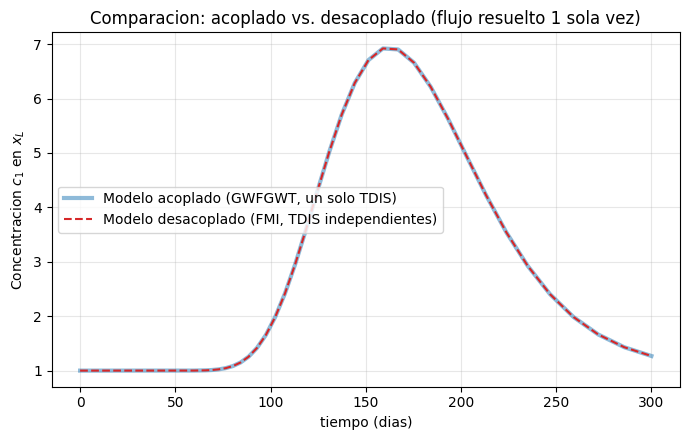

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))

c_xL_acoplado = np.array([ucn.get_data(totim=t)[0, 0, -1] for t in times])
c_xL_desacoplado = np.array([ucn2.get_data(totim=t)[0, 0, -1] for t in times2])

ax.plot(times, c_xL_acoplado, lw=3, color="#1f77b4", alpha=0.5,
        label="Modelo acoplado (GWFGWT, un solo TDIS)")
ax.plot(times2, c_xL_desacoplado, lw=1.5, ls="--", color="#d62728",
        label="Modelo desacoplado (FMI, TDIS independientes)")
ax.set_xlabel("tiempo (dias)")
ax.set_ylabel("Concentracion $c_1$ en $x_L$")
ax.set_title("Comparacion: acoplado vs. desacoplado (flujo resuelto 1 sola vez)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 ¿Cuándo conviene desacoplar flujo y transporte?

- **Flujo en estado permanente** (como en este ejemplo): el flujo se
  resuelve una única vez y se reutiliza para cualquier discretización
  temporal de transporte que se desee explorar (más fina, más gruesa,
  distintos escenarios), sin recalcularlo.
- **Flujo transitorio, pero mucho más lento que el transporte**: se puede
  seguir usando `FMI`, guardando cargas y caudales del `GWF` con pasos de
  tiempo relativamente gruesos, mientras el `GWT` usa pasos mucho más finos
  (necesarios por criterios de estabilidad/precisión numérica de la
  advección) interpolando/reusando el mismo campo de flujo entre guardados.
- **Múltiples corridas de transporte con el mismo flujo**: por ejemplo,
  simular varios escenarios de contaminación (distintas condiciones
  iniciales o de frontera de concentración) sin tener que resolver el flujo
  cada vez — se corre el `GWF` una sola vez y se reutiliza su salida en
  cuantas simulaciones de `GWT` (con `FMI`) se necesiten.

La limitación es que el modelo de transporte por `FMI` sólo puede **leer**
el flujo ya calculado; no puede haber retroalimentación del transporte hacia
el flujo (p. ej. cambios de densidad por concentración), caso en el cual sí
es obligatorio el acoplamiento con `GWFGWT` como en la sección 3.

## 6. Resumen

- El problema se planteó como un sistema acoplado de dos EDPs: la ecuación
  de flujo subterráneo para $h(x,t)$ y la ecuación de advección-dispersión
  para $c_1(x,t)$, con las condiciones iniciales y de frontera dadas en la
  figura.
- Se identificó que las condiciones de frontera de flujo, tal como se
  presentan, no bastan para generar movimiento de agua (y por tanto
  transporte advectivo), por lo que se agregó un pozo de inyección en $x_1$
  como fuente necesaria, coherente con la condición de concentración fija
  especificada en ese mismo punto.
- El modelo se resolvió con **MODFLOW 6**, acoplando un modelo de flujo
  (`GWF`) en régimen permanente con un modelo de transporte (`GWT`)
  transitorio, usando FloPy para la construcción, ejecución y post-proceso.
- Los resultados muestran cómo el pulso inicial de concentración en
  $x_{12}$ se advecta y dispersa hacia la salida $x_L$, mientras el frente
  de agua inyectada en $x_1$ (con concentración de fondo) avanza detrás de
  él.
- Se mostró además que **flujo y transporte pueden desacoplarse en dos
  simulaciones independientes**, cada una con su propio `TDIS`, enlazadas
  mediante el paquete `FMI`. Esto permite resolver el flujo una sola vez
  (cuando es permanente, o cuando cambia mucho más lento que el transporte)
  y reutilizarlo con la discretización temporal que el transporte
  realmente necesite, sin recalcular innecesariamente el campo de flujo en
  cada paso de tiempo.

Este mismo flujo de trabajo (definición de EDPs → identificación de datos
faltantes → construcción del modelo por paquetes → ejecución → post-proceso)
es directamente extensible a dominios 2D/3D, múltiples especies químicas,
reacciones o condiciones transitorias más complejas.